# Комп'ютерний практикум №1

**Тема роботи:** Дослідження дискретних марковських процесів прийняття рішень та оцінювання заданих політик.

## Статистична частина в середовищі *FrozenLake*

*FrozenLake* — класичний приклад середовища типу *gridworld* у бібліотеці **Gymnasium**. На його прикладі ми дослідимо, як карта та правила руху визначають переходи між станами MDP.

Документація FrozenLake - [https://gymnasium.farama.org/environments/toy_text/frozen_lake/](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

**В даному ноутбуці виконаємо статистичну частину завдання для *FrozenLake***:

Проведіть серію епізодів за кожною політикою. Оцініть частки успішних епізодів, потраплянь в ополонку та епізодів, зупинених через обмеження кількості кроків. Порівняйте результати моделювання з розрахунками та поясніть можливі розбіжності.



In [93]:
import sys
import os
import gymnasium as gym

import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#import time

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Функції в рамках поточного курсу :)
from libraries import fdrl26_fl as fl  # для FrozenLake
from libraries import fdrl26_rl as rl  # класика RL

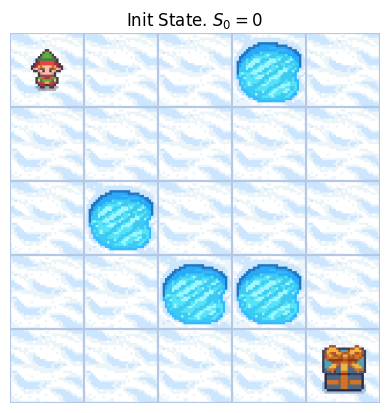

In [94]:
# середовище з власною картою
FL_map = ['SFFHF', 'FFFFF', 'FHFFF', 'FFHHF', 'FFFFG'] # my_map_5x5

env = gym.make(
     "FrozenLake-v1",
     is_slippery = True,          # Чи є ковзання True / False
     desc = FL_map,               # Використовуємо власну карту
     max_episode_steps = 400,     # Максимальна кількість кроків
     render_mode="rgb_array"      # обираємно "rgb_array"!  ("human", "None")
    )

map_size = len (FL_map)   # Map Size  NxN

nS = env.observation_space.n   # кількість станів (залежить від map_size)
nA = env.action_space.n        # кількість дій (для FL завжди 4):
action_symbols = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}   # L,D,R,U
action_arrows  = {0: '←', 1: '↓', 2: '→', 3: '↑'}

state, info = env.reset()

# render the environment
pic=env.render()
fl.plot_img (pic, -1, state, 0, 0, 0)

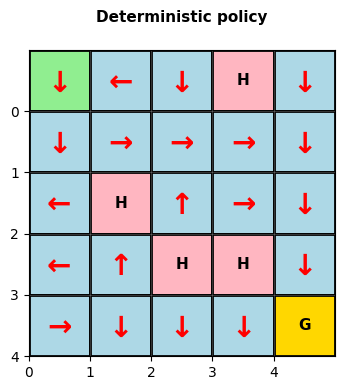

In [95]:
# 0(← L),  1(↓ D),  2(→ R),  3(↑ U),  0 (. 0) (No action, для термінальних станів)
policy_det_symbolic = [     # символьне завдання
    '↓ ← D . D',            # policy_det
    '↓ R R R D',            # за допомогою
    '← . ↑ R D',            # символів:
    '← U 0 0 D',            # L  D  R  U   .
    '→ ↓ ↓ ↓ 0']            # ←  ↓  →  ↑   0

# Deterministic policy - в вигляді вектору з номер дії для кожного стану
policy_det = fl.policy_symbolic_to_deterministic(policy_det_symbolic)
#print(policy_det.reshape(5, 5))

# Deterministic policy - можна відобразити на карті
fl.plot_deterministic_policy(policy_det, FL_map, title="Deterministic policy")

In [96]:
# Для подальших розрахунків deterministic policy перетворимо на stochastic policy
# policy[s][a] = ймовірність вибору дії a в стані s, тобто p(a|s)

# При epsilon=0 політика залишається детермінованою,
# хоч і в форматі ймовірностей p(a|s)
# При epsilon=1 політика має рівноймовірний вибір дій

policy1 = rl.policy_deterministic_to_stochastic (policy_det, nA, epsilon=1.00)
policy2 = rl.policy_deterministic_to_stochastic (policy_det, nA, epsilon=0.00)

print ('policy1=')
print(policy1)

print ('\npolicy2=')
print(policy2)

policy1=
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

policy2=
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]


In [97]:
# Задаємо власне обране значення gamma
gamma = 0.94

# обираємо політику policy1 або policy2
policy = policy1

G0, steps, trajectory = rl.run_episode(env, policy, gamma)
print (trajectory)

## аналіз траєкторії адаптована під FL
#
fl.print_trajectory(trajectory)
fl.print_result(trajectory)
print(f"Дисконтований дохід: {G0:.4f}")
#

[(0, 1, 0.0, 0, False, False), (0, 3, 0.0, 0, False, False), (0, 3, 0.0, 0, False, False), (0, 2, 0.0, 5, False, False), (5, 0, 0.0, 10, False, False), (10, 3, 0.0, 10, False, False), (10, 0, 0.0, 10, False, False), (10, 0, 0.0, 5, False, False), (5, 0, 0.0, 5, False, False), (5, 0, 0.0, 0, False, False), (0, 0, 0.0, 0, False, False), (0, 1, 0.0, 1, False, False), (1, 3, 0.0, 1, False, False), (1, 2, 0.0, 6, False, False), (6, 3, 0.0, 7, False, False), (7, 2, 0.0, 12, False, False), (12, 0, 0.0, 17, True, False)]
 t |  s | дія | винагорода | s' | завершення
-------------------------------------------------------
 0 |  0 |  ↓  |          0 |  0 | 
 1 |  0 |  ↑  |          0 |  0 | 
 2 |  0 |  ↑  |          0 |  0 | 
 3 |  0 |  →  |          0 |  5 | 
 4 |  5 |  ←  |          0 | 10 | 
 5 | 10 |  ↑  |          0 | 10 | 
 6 | 10 |  ←  |          0 | 10 | 
 7 | 10 |  ←  |          0 |  5 | 
 8 |  5 |  ←  |          0 |  5 | 
 9 |  5 |  ←  |          0 |  0 | 
10 |  0 |  ←  |          0 |  

In [98]:
#  ТРОШКИ СТАТИСТИКИ :)

# Для вашої фантазії.
# Запускаєм епізод 10000 разів (run_episode)

# Накопичуємо статистику:
# - скільки успіхів
# - яка усереднена нагорода
# - в яких клітинках завершилась гра, з якою ймовірністтю...

import pandas as pd
from collections import defaultdict

attempts = 10000
success_count = 0
reward_sum = 0
terminal_state_dict = defaultdict(int)

for i in range(attempts):
    episode_data = rl.run_episode(env, policy, gamma)
    steps_list = episode_data[2]
    last_step = steps_list[-1]
    
    state, action, reward, next_state, terminated, truncated = last_step
    
    reward_sum += reward
    terminal_state_dict[next_state] += 1
    if reward > 0:
        success_count += 1

success_rate = (success_count / attempts) * 100
average_reward = reward_sum / attempts

df_terminal = pd.DataFrame(list(terminal_state_dict.items()), columns=['State', 'Count'])
df_terminal['Probability'] = df_terminal['Count'] / attempts

df_terminal = df_terminal.sort_values(by='State').reset_index(drop=True)

print(f"Успішність: {success_rate:.2f}% ({success_count} з {attempts})")
print(f"Середня винагорода: {average_reward:.4f}\n")

print("Розподіл кінцевих станiв:")
display(df_terminal)

Успішність: 1.32% (132 з 10000)
Середня винагорода: 0.0132

Розподіл кінцевих станiв:


,State,Count,Probability
0,3,2777,0.2777
1,11,5641,0.5641
2,17,1012,0.1012
3,18,438,0.0438
4,24,132,0.0132
